In [1]:
import os
import sys
sys.path.append(os.path.expanduser('~'))
import numpy as np 
from matplotlib import pyplot as plt
from datetime import datetime as dt
import figures as fgs
from albatros_analysis.src.correlations import baseband_data_classes as bdc
from albatros_analysis.src.utils import baseband_utils as butils
from albatros_analysis.src.utils import orbcomm_utils as outils
import numba as nb
import time
import importlib
import json
from scipy.optimize import minimize
from skyfield.api import load, wgs84
import cupy
import fitting_helper as fh

BDC is using numpy
BDC is using numpy


In [2]:
@nb.njit(parallel=True)
def apply_delay(arr, out, delay, freqs):
    # apply delay to an array of complex electric field or their correlation
    # does exp( j 2 pi nu tau) sign of tau is user dependent
    # freqs should correspond to the columns of the nspec x nchan array
    nspec = arr.shape[0]
    nchan = arr.shape[1]
    for i in nb.prange(nspec):
        for j in range(nchan):
            out[i, j] = arr[i, j] * np.exp(2j * np.pi * freqs[j] * delay[i])
    return out

@nb.njit(parallel=True)
def apply_delay_1d(arr, out, delay, freq):
    # apply delay to an array of complex electric field or their correlation
    # does exp( j 2 pi nu tau) sign of tau is user dependent
    # freqs should correspond to the columns of the nspec x nchan array
    nspec = arr.shape[0]
    for i in nb.prange(nspec):
            out[i] = arr[i] * np.exp(2j * np.pi * freq * delay[i])
    return out

@nb.njit(parallel=True)
def xcorr_avg(arr1,arr2,acclen):
    #helper function
    nblocks = arr1.shape[0]//acclen
    nchan = arr1.shape[1]
    out = np.zeros((nblocks,nchan),dtype=arr1.dtype)
    for i in nb.prange(nblocks):
        for j in range(acclen):
            for k in range(nchan):
                out[i,k] += arr1[i*acclen + j,k]*np.conj(arr2[i*acclen + j,k])
        out[i,:]/=acclen
    return out

@nb.njit(parallel=True)
def xcorr_avg_1d(arr1,arr2,acclen):
    #helper function
    nblocks = arr1.shape[0]//acclen
    out = np.zeros((nblocks,),dtype=arr1.dtype)
    for i in nb.prange(nblocks):
        for j in range(acclen):
                out[i] += arr1[i*acclen + j]*np.conj(arr2[i*acclen + j])
        out[i]/=acclen
    return out

In [3]:
def beamformed_xcorr(data, ant1_idx, ant2_idx, pol1_idx, pol2_idx, delay, freqs, acclen):
    nants, npols, nspec, nchans = data.shape
    assert len(freqs) == nchans
    assert len(delay) == nspec
    spec1=data[ant1_idx,pol1_idx,:,:].copy()
    spec2=data[ant2_idx,pol2_idx,:,:].copy()
    spec2_phased = np.empty_like(spec2)
    spec2_phased = apply_delay(spec2, spec2_phased, -delay, freqs)
    V = xcorr_avg(spec1,spec2_phased,acclen)
    return V


def efield_to_vis(
    data_all,
    t_start,
    t_end,
    ant_idxs,
    ant_coords,
    satID,
    sat_freqs,
    acclen = 1024,
    osamp = 64,
    bb_spectrum_T = 4096/250e6
):

    """ 
    Notes: require t_start to coincide with the first spectrum of data_all.
    As long as t_end is after the last spectrum, the interpolation is fine.
    """
    T_SPECTRA = bb_spectrum_T * osamp
    nspec = int((t_end - t_start)/T_SPECTRA)
    nants = len(ant_idxs)
    print(nspec)
    data_all = data_all[:, :, :nspec, :]
    print(data_all.shape)
    tle_path = outils.get_tle_file(t_start, "/project/rrg-sievers/mohanagr/OCOMM_TLES")
    sats_objects = load.tle_file(tle_path)
    V = []
    arr_spectra = np.arange(0, nspec) * T_SPECTRA
    arr_times = np.arange(0, int(t_end-t_start)+1)
    for i in range(nants):
        ant1_idx = ant_idxs[i]
        ant1_coords = ant_coords[ant1_idx]
        for j in range(i+1, nants):
            ant2_idx = ant_idxs[j]
            ant2_coords = ant_coords[ant2_idx]

            dly = outils.get_sat_delay2(
                                ant1_coords,
                                ant2_coords,
                                sats_objects,
                                t_start,
                                int(t_end-t_start)+1,
                                satID,
                                altaz=False
                        )
            print(dly.shape)

            delay = np.interp(arr_spectra, arr_times, dly)
            print(delay.shape)

            Vxx = beamformed_xcorr(data_all, ant1_idx, ant2_idx, 0, 0, delay, sat_freqs, acclen)
            Vyy = beamformed_xcorr(data_all, ant1_idx, ant2_idx, 1, 1, delay, sat_freqs, acclen)
            vis=(Vxx+Vyy)/2
            V.append(np.abs(vis))
    return np.array(V)

def plot_all_blines(V, ant_idxs, ant_nums):
    """
    Plot all baselines in a 3-column grid, each with its own colorbar.
    
    V: (Nbl, Nfreq, Ntime)
    ant_idxs: list of antenna indices used to form baselines
    """
    Nbl, Nfreq, Ntime = V.shape
    nants = len(ant_idxs)

    ncols = 3
    nrows = int(np.ceil(Nbl / ncols))

    # Make plots longer by adjusting height
    fig, ax = plt.subplots(nrows, ncols,
                           figsize=(5*ncols, 4*nrows),
                           sharex=True, sharey=True)

    # Ensure ax is always 2D
    ax = np.atleast_2d(ax)

    bline_idx = 0
    for i in range(nants):
        ant1_idx = ant_idxs[i]
        for j in range(i+1, nants):
            ant2_idx = ant_idxs[j]

            # Compute row, col in the grid
            r = bline_idx // ncols
            c = bline_idx % ncols

            im = ax[r, c].imshow(V[bline_idx, :, :],
                                 aspect='auto',
                                 interpolation='nearest')
            fig.colorbar(im, ax=ax[r, c], fraction=0.046, pad=0.04, label='|V|')
            ax[r, c].set_title(f'Ant {ant_nums[ant1_idx]} - Ant {ant_nums[ant2_idx]}')

            bline_idx += 1

    # Hide any unused subplots
    for idx in range(Nbl, nrows*ncols):
        r = idx // ncols
        c = idx % ncols
        ax[r, c].axis('off')

    plt.tight_layout()
    plt.show()

In [4]:
path_config = '/home/thomasb/albatros_analysis/scripts/orbcomm/config/config_batch2.json'
path_cutter = '/scratch/thomasb/full_timing_discrepancies_1753200150/cutting.json'
path_pulses = '/scratch/thomasb/full_timing_discrepancies_1753200150/pulses2.json'

In [5]:
#open config and get metadata
with open(path_config, "r") as f:
    config = json.load(f)
ant_names, ant_coords, dir_parents, spec_offsets = [], [], [], []
# Call get_starting_index for all antennas except reference
for i, (ant, details) in enumerate(config["antennas"].items()):
    dir_parents.append(details["path"])
    spec_offsets.append(details["clock_offset"])
    ant_names.append(details["name"])
    ant_coords.append(details["coordinates"])

ant_numbers = np.array([int(name.split()[1]) for name in ant_names])
batch_start_ts = config["correlation"]["start_timestamp"]
batch_end_ts = config["correlation"]["end_timestamp"]
chanstart = config["frequency"]["start_channel"]
chanend = config["frequency"]["end_channel"]
osamp = config["correlation"]["osamp"]
pfb_size = config["correlation"]["pfb_size"]
new_acclen = config["correlation"]["new_acclen"]

new_chunk_len = (new_acclen*4096*osamp)/250e6
tle_path = outils.get_tle_file(batch_start_ts, "/project/rrg-sievers/mohanagr/OCOMM_TLES")
print(new_acclen)
print(batch_start_ts)
print(batch_end_ts)

1024
1753200150
1753286410


In [6]:
with open(path_pulses, "r") as f:
    pulses = json.load(f)

In [ ]:
idx_pulse = 0

pulse = pulses[idx_pulse]
pulse_start_ts = pulse['t_start']
pulse_end_ts = pulse['t_end']
satID = pulse['sat']
chan_det = pulse['channel']

ant_idxs = [0, 2, 3, 4, 5, 6]
ant_nums = [1, 2, 4, 5, 6, 7, 8]

if chan_det%2 == 0:
    old_chans = np.arange(chan_det-2, chan_det+2)
else:
    old_chans = np.arange(chan_det-1, chan_det+3)

print(old_chans)
old_chans_big = old_chans+1834

chans_new = np.arange(osamp) + old_chans[:, None] * osamp
chans_new = chans_new.ravel()

sat_freqs = 250e6 - ((chans_new/osamp + 1834)/(4096/250e6))


[6 7 8 9]


In [8]:
fname = f'data_raw_osamp={osamp}_start={pulse_start_ts}_end={pulse_end_ts}_chans={old_chans_big[0]}:{old_chans_big[-1]}.npy'
disk_path = f'/scratch/thomasb/full_timing_discrepancies_{batch_start_ts}/{fname}'
print(fname)

data_raw_osamp=64_start=1753200455_end=1753200749_chans=1840:1843.npy


In [9]:
data = np.load(disk_path)

In [10]:
nants, npols, nspec, nchans = data.shape
print('Data shape', data.shape)

Data shape (7, 2, 279552, 256)


In [11]:
V = efield_to_vis(
    data,
    pulse_start_ts,
    pulse_end_ts-1,
    ant_idxs,        
    ant_coords,
    satID,
    sat_freqs,
    acclen = new_acclen,
    osamp = osamp,
    bb_spectrum_T = 4096/250e6)

279426
(7, 2, 279426, 256)
(294,)
(279426,)
(294,)
(279426,)
(294,)
(279426,)
(294,)
(279426,)
(294,)
(279426,)
(294,)
(279426,)
(294,)
(279426,)
(294,)
(279426,)
(294,)
(279426,)
(294,)
(279426,)
(294,)
(279426,)
(294,)
(279426,)
(294,)
(279426,)
(294,)
(279426,)
(294,)
(279426,)


In [12]:
V.shape

(15, 272, 256)

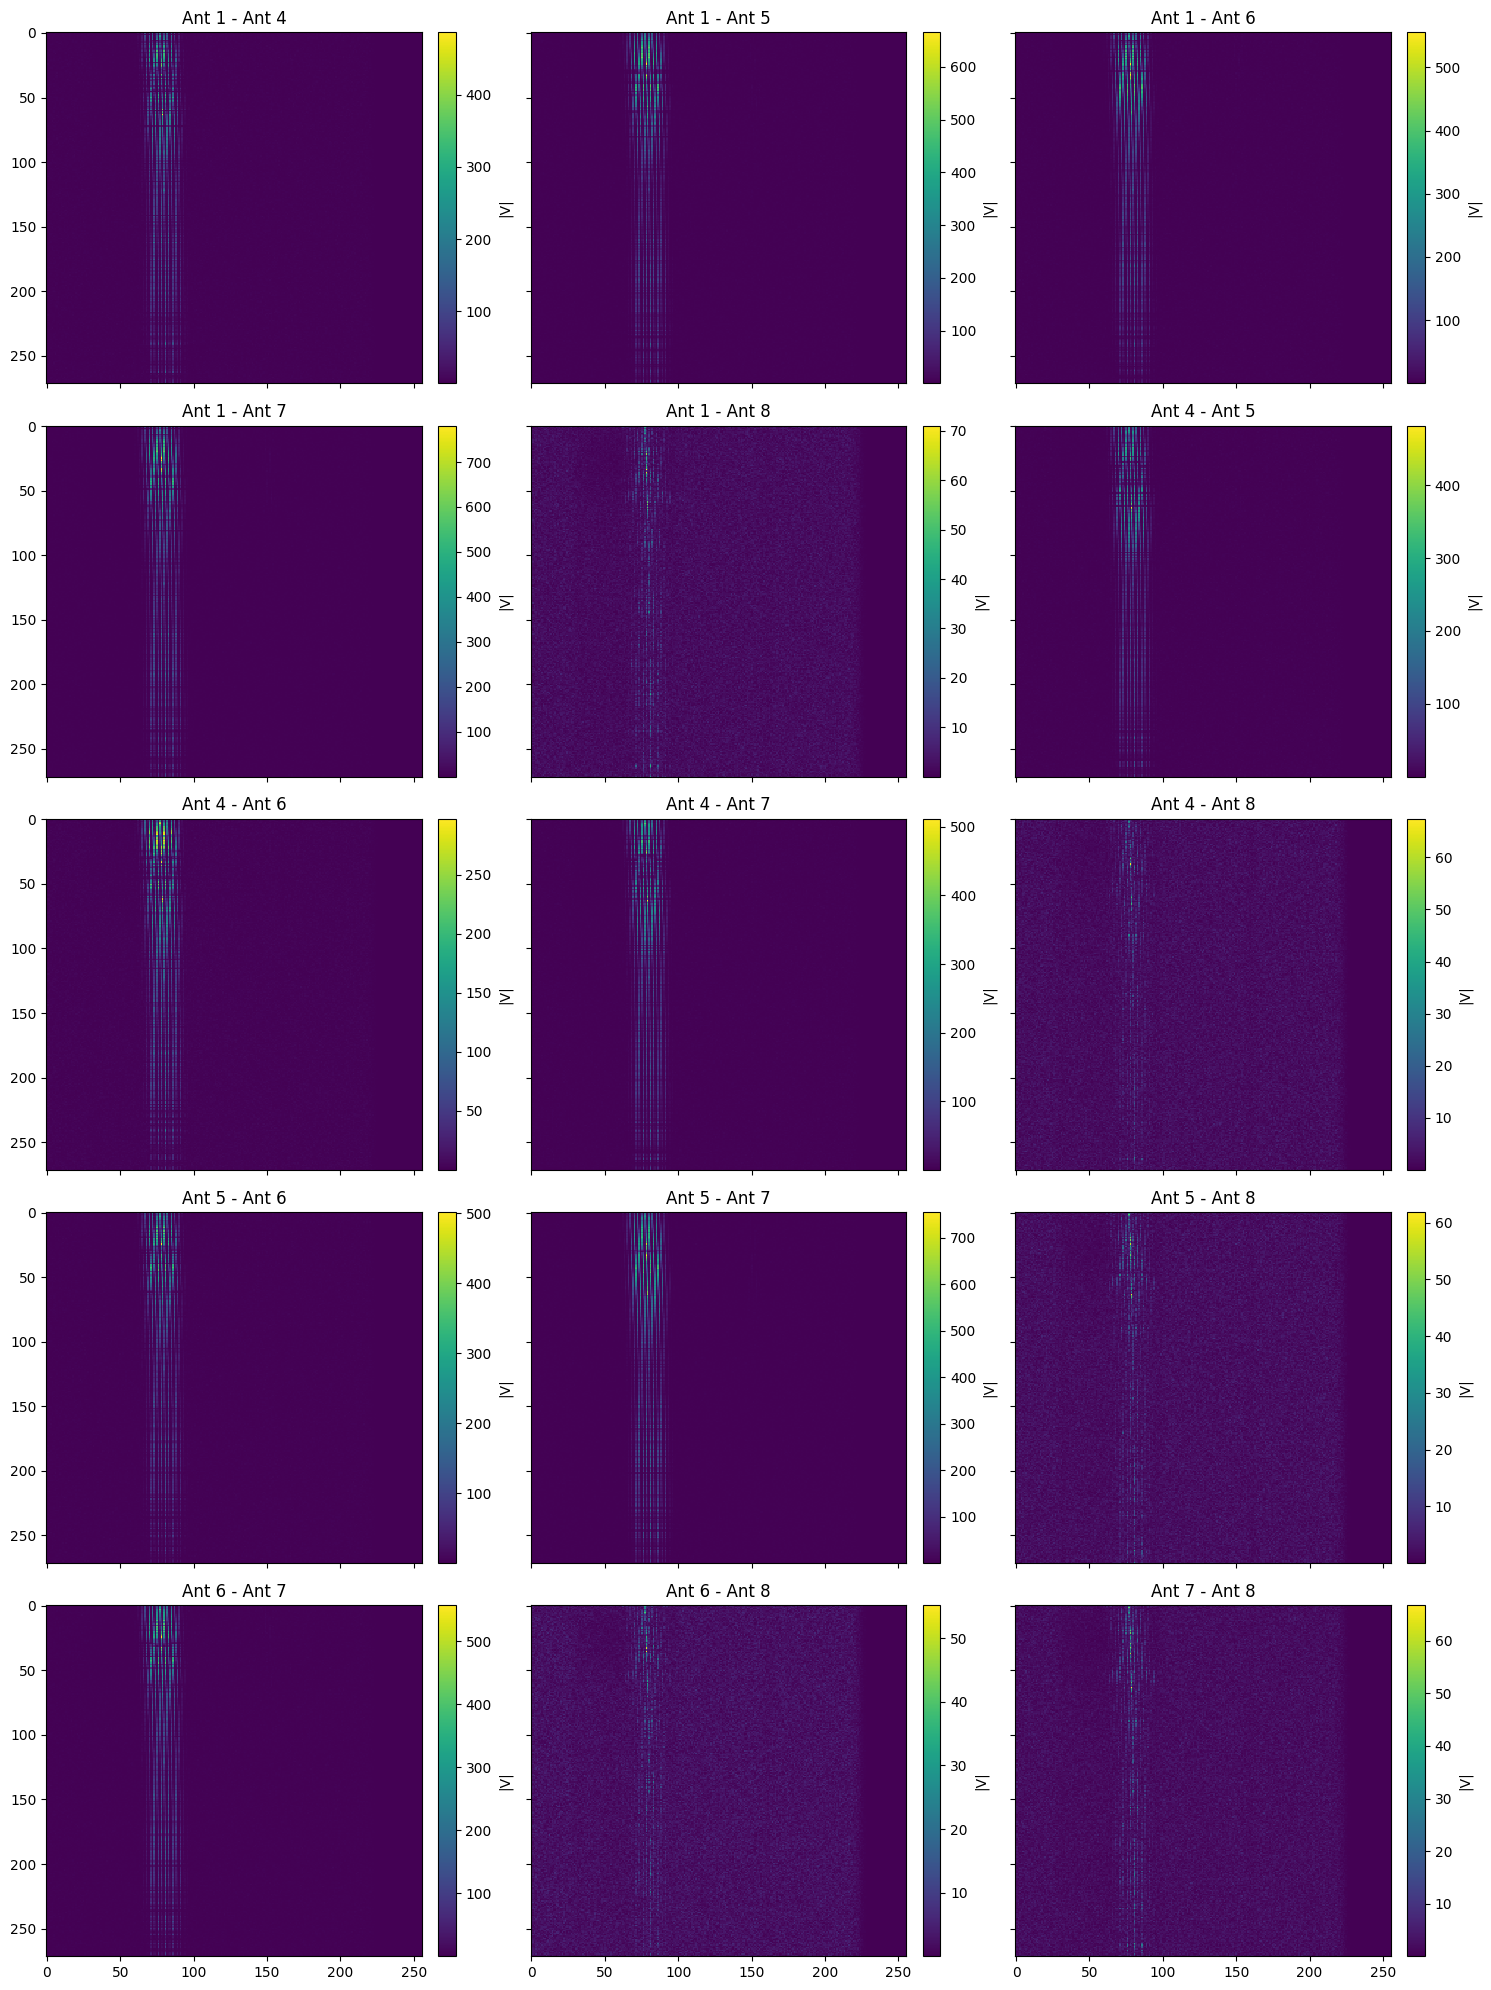

In [13]:
plot_all_blines(V, ant_idxs, ant_nums)

In [14]:
chunks_cut_start = 0
chunks_cut_end = 120

spectra_cut_start = chunks_cut_start * new_acclen
spectra_cut_end = (chunks_cut_end) * new_acclen
assert spectra_cut_end > 0

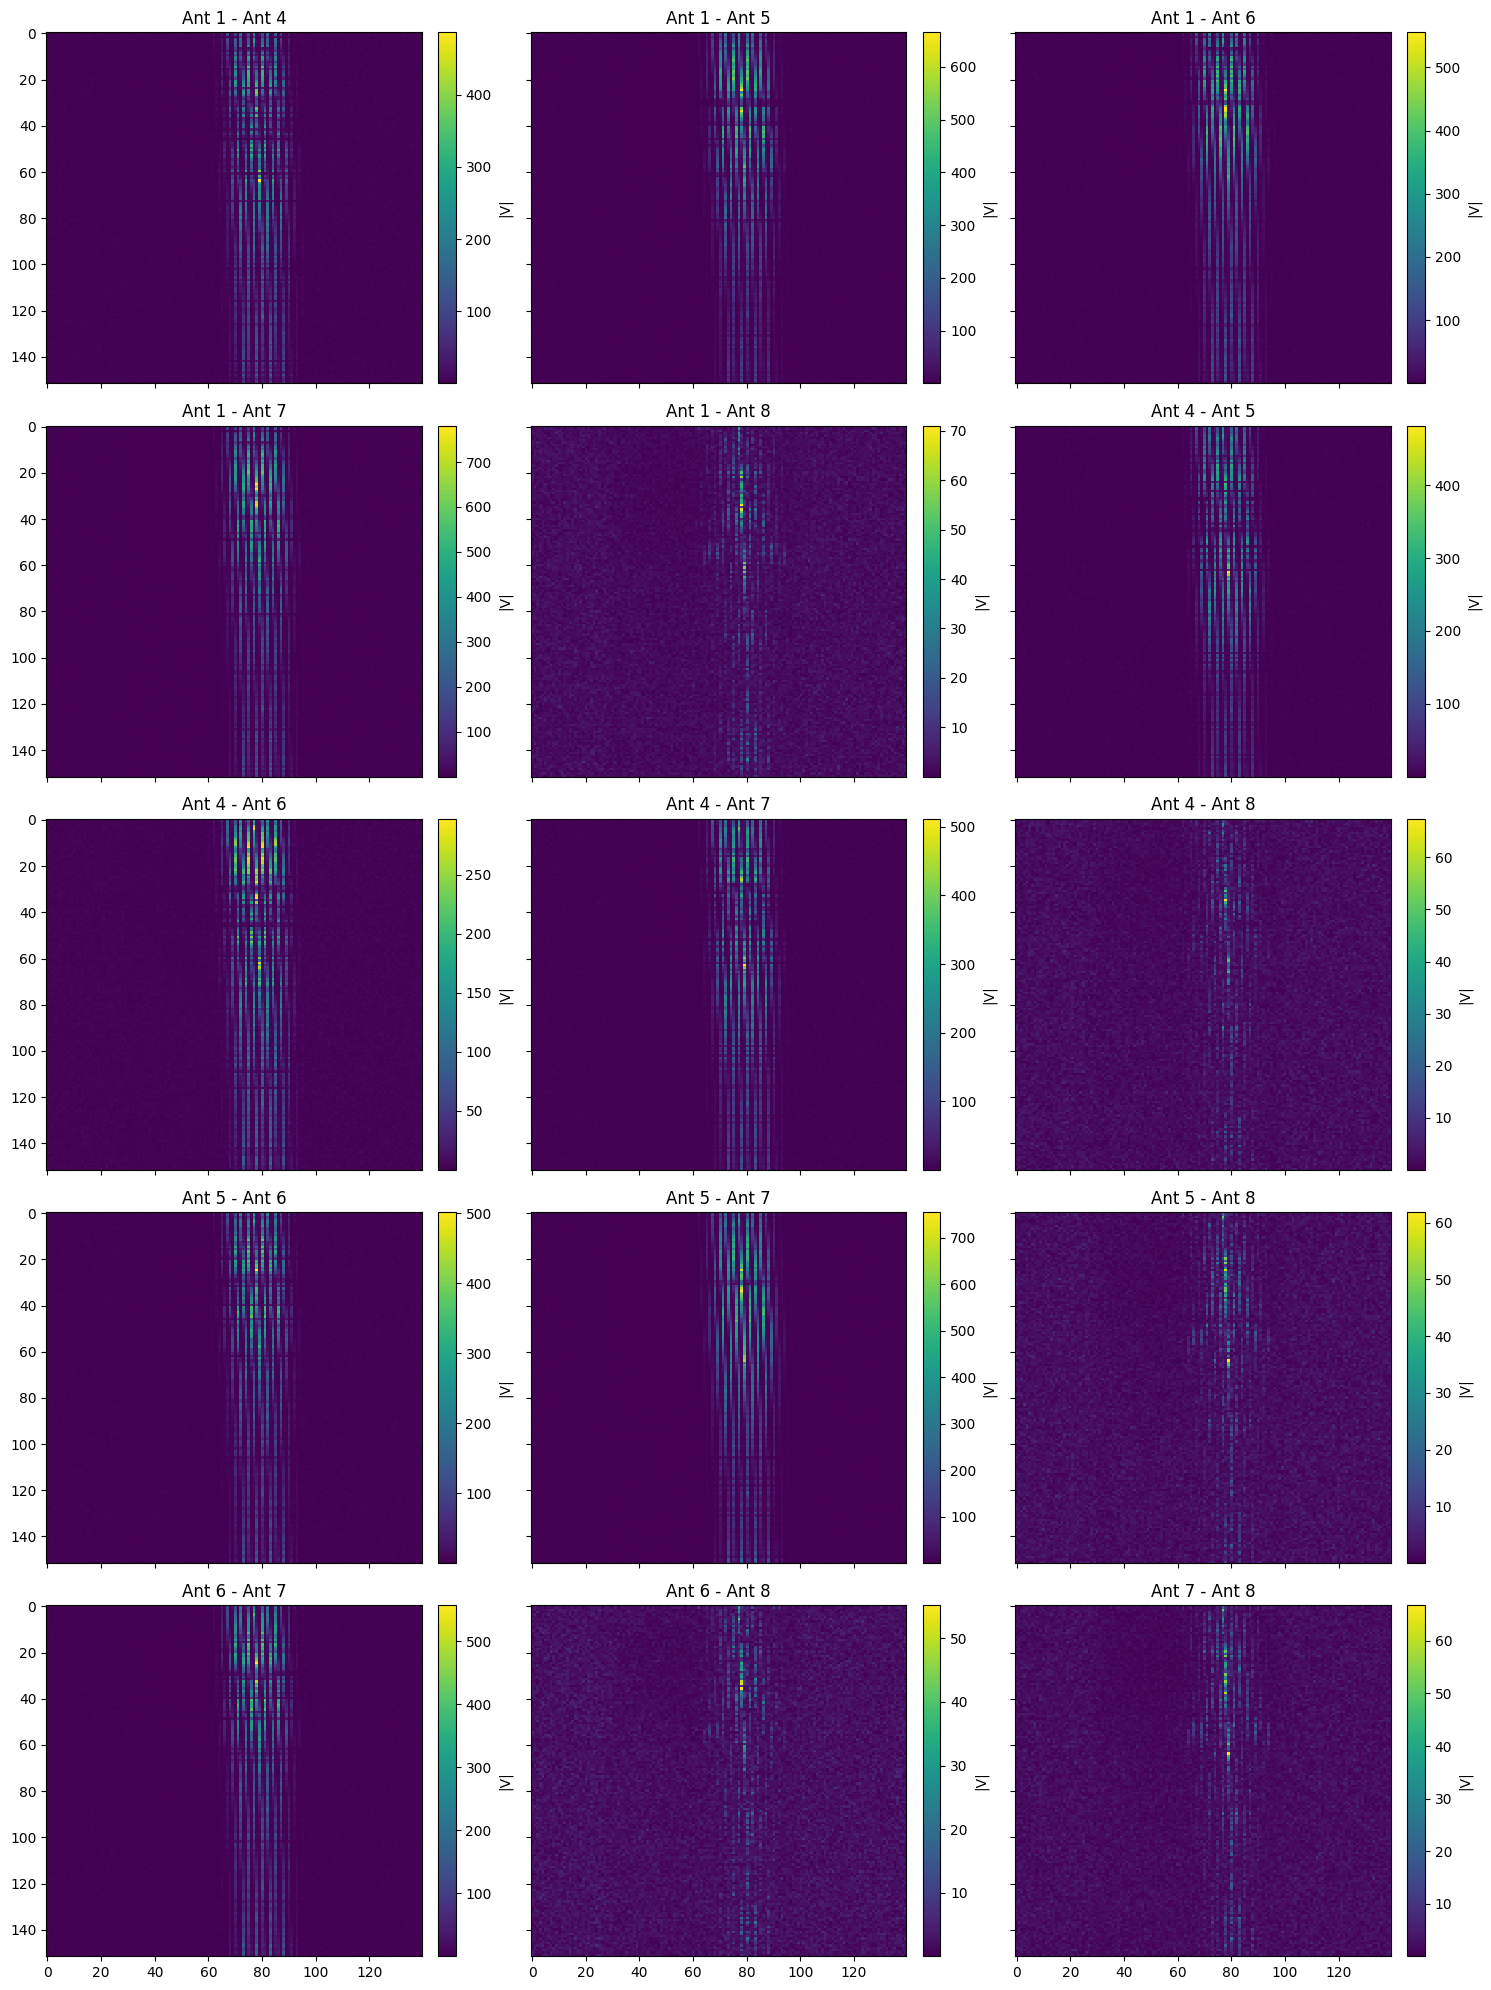

In [15]:
plot_all_blines(V[:, chunks_cut_start:-chunks_cut_end, :140], ant_idxs, ant_nums)

In [16]:
new_chans = [72, 88]

In [17]:
with open(path_cutter, "r") as f:
    cutter = json.load(f)
cutter.setdefault(fname, {})
cutter[fname]['sat'] = satID
cutter[fname]['new_chans'] = new_chans
cutter[fname]['spectra_start'] = spectra_cut_start
cutter[fname]['spectra_end'] = spectra_cut_end

with open(path_cutter, "w") as f2:
    json.dump(cutter, f2, indent=4)

In [ ]:
#might want multiple channels for more stable solution
#might want to make cutting more straightforward, find better way to slice it?